# Title:: Spring mass system 
# Description: A spring mass system with single degree of freedom is simulated by computing the governing equation based on energy methods.  
# Contact:: vinothdhanavel2503@gmail.com

In [9]:
## import Modules
from sympy import *
from sympy.physics.mechanics import *
init_vprinting()

## Governing equation
m,k,g,t =symbols("m k g t")
x=dynamicsymbols("x")

vel=diff(x,t)
acc=diff(vel,t)

## Defining Lagrangian
KE= 0.5*m*(vel**2)
PE=0.5*k*(x**2) - m*g*x

lgr= KE - PE
eqn=diff(diff(lgr,vel),t) - diff(lgr,x)
sln=solve(eqn,acc)[0]
Eq(acc,sln)

In [10]:
##import Modules
import numpy as np
from scipy.integrate import solve_ivp

## solve the Governing Equation
# system constants & initial conditions
g=9.81
m=1
k=10

##initial conditions
x0=-1
vel0=0

## solve 
def spring_mass_g(t,y):
    return (y[1],g - (y[0])*k/m)

sol = solve_ivp(spring_mass_g,[0,10],[x0,vel0],t_eval=np.linspace(0,10,101))
x,vel=sol.y
t=sol.t

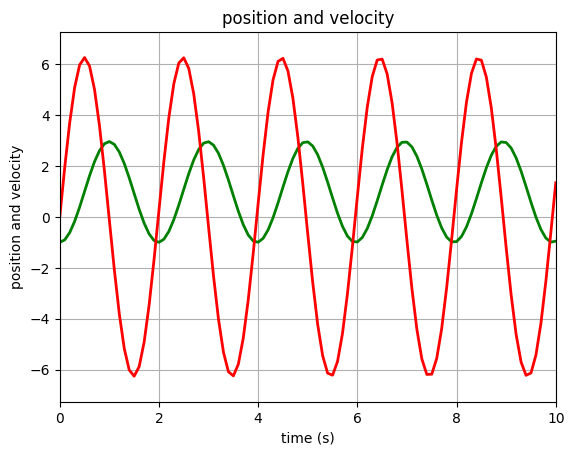

In [11]:
## import modules
import matplotlib.pyplot as plt
from matplotlib.animation import Animation

# plot spring mass system
fig_curve,ax=plt.subplots()

ax.set_title("position and velocity")
ax.set_xlim(0,10)
ax.set_ylim(-max(vel) -1,max(vel)+1)
ax.set_xlabel("time (s)")
ax.set_ylabel("position and velocity")
ax.plot(t,x,"g",lw=2)
ax.plot(t,vel,"r",lw=2)
ax.grid()
plt.show()

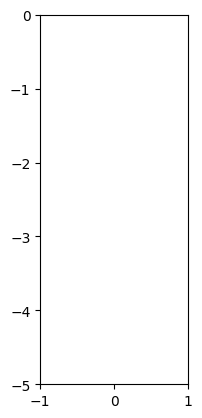

In [12]:
# animate 
fig=plt.figure()
ax=fig.add_subplot(aspect="equal")
ax.set_xlim(-1,1)
ax.set_ylim(-5,0)

## Generate spring
def generate_spring(n):
    points=np.zeros((2,n+2))
    points[:,-1]=[0,-1]

    for i in range(1,n+1):
        points[0,i]= -1/(2*n) if i%2==0 else 1/(2*n)
        points [1,i]= -((2*i -1 )/(2*n))
    return points 

In [13]:
from matplotlib.lines import Line2D 
points = np.append(generate_spring(30),np.ones((1,32)),axis=0)
## unstrecthed spring
ulen=2
y0= -(ulen+x0)
spring=Line2D(points[0,:],points[1,:], color="r")
circle = ax.add_patch(plt.Circle((0,y0),0.25,fc="g", zorder=2))
ax.add_line(spring)
plt.show()

In [14]:
from matplotlib.transforms import Affine2D

def animate(i):
    y=-(ulen+x[i]) ## y cordinate or the poisition of mass at any given time
    circle.set_center((0,y))

    stretch_factor=-y ## why 
    aff_trans=Affine2D().scale(8/stretch_factor,stretch_factor).get_matrix()
    dyn_points=np.matmul(aff_trans,points)

    ## new points
    xn=dyn_points[0,:]
    yn=dyn_points[1,:]

    ## update the spring
    spring.set_data(xn,yn)

In [15]:
import matplotlib as mpl
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
anim=animation.FuncAnimation(fig,animate,frames=len(t))
writer=FFMpegWriter(fps=30)
anim.save("spring_mass.mp4",writer=writer)
anim.save("spring_mass_gif.gif",writer=writer)